In [1]:
from pickle import load
import pandas as pd
from sklearn.model_selection import train_test_split
import shap
import numpy as np
import matplotlib.pyplot as plt

/home/steve/Documents/FormationIA/Projet-immo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Test

In [2]:
pipe_path = "../model/20251021-15h51m49_rf.pkl"
data_path = "../data/clean/dvf.csv"

In [3]:
def load_pipeline(pipe_path):
    with open(pipe_path, "rb") as f:
        return load(f)

In [4]:
def load_df(data_path):
    return pd.read_csv(data_path, low_memory=False, nrows=10000)

In [5]:
pipe = load_pipeline(pipe_path)

In [6]:
df = load_df(data_path)

In [7]:
def generate_Xy(df:pd.DataFrame):
    y = df['Valeur fonciere']
    X = df.drop(columns=['Valeur fonciere', 'Code departement'])
    return X,y

In [8]:
def generate_train_test(X, y, test_size, random_state):
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

In [9]:
X, y = generate_Xy(df)
X_train, X_test, y_train, y_test = generate_train_test(X, y, test_size=0.3, random_state=8)

In [10]:
# Get scaled data
X_test_scaled = pipe.named_steps['scaler'].transform(X_test)

In [11]:
# SHAP analysis
explainer = shap.TreeExplainer(pipe.named_steps['rf'])
shap_values = explainer.shap_values(X_test_scaled)

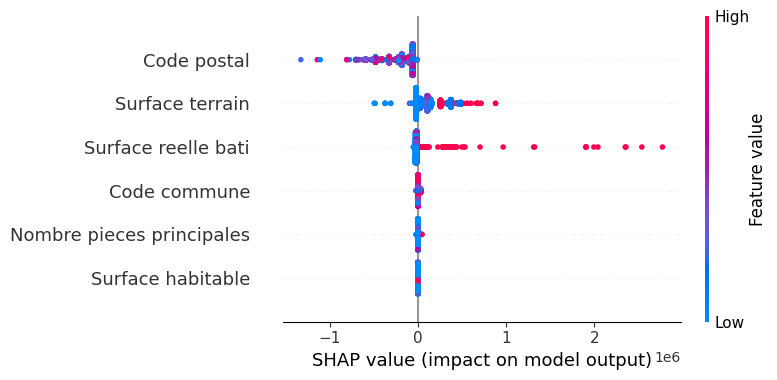

In [12]:
# Visualizations
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

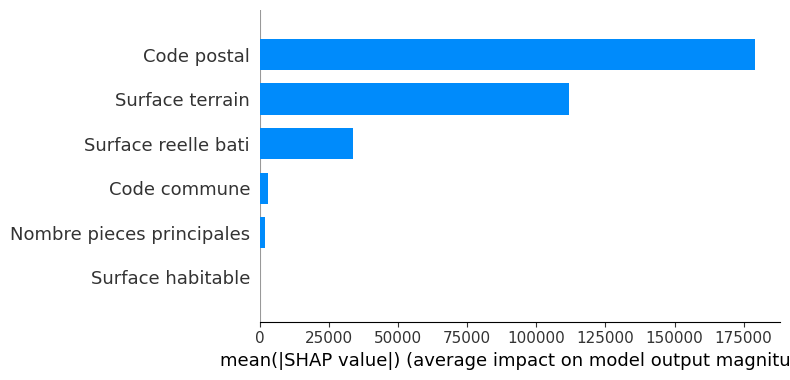

In [13]:
# Feature importance plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar")

In [14]:
# Individual prediction explanation
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test_scaled[0], 
                feature_names=X.columns)

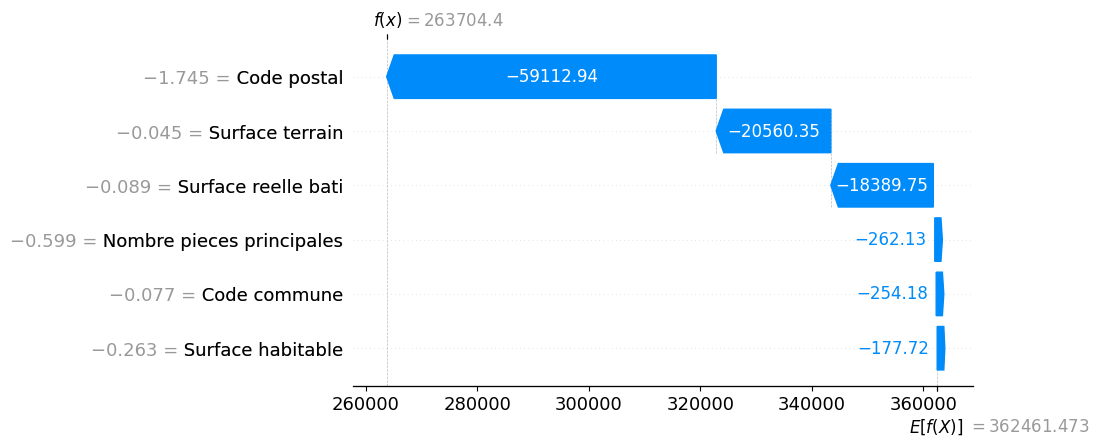

In [15]:
# Waterfall plot for single prediction
shap.plots.waterfall(shap.Explanation(values=shap_values[0], 
                                       base_values=explainer.expected_value,
                                       data=X_test_scaled[0],
                                       feature_names=X.columns))

In [16]:
rs = np.random.RandomState(0)
df = pd.DataFrame(X_test_scaled)
df.columns = X_test.columns
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,Code postal,Code commune,Surface habitable,Nombre pieces principales,Surface reelle bati,Surface terrain
Code postal,1.000000,0.220739,-0.098365,-0.005556,0.016339,0.038674
Code commune,0.220739,1.000000,-0.062277,0.010471,0.023900,0.036694
Surface habitable,-0.098365,-0.062277,1.000000,0.193384,0.072972,-0.097213
Nombre pieces principales,-0.005556,0.010471,0.193384,1.000000,0.232598,-0.111254
Surface reelle bati,0.016339,0.023900,0.072972,0.232598,1.000000,-0.037290
Surface terrain,0.038674,0.036694,-0.097213,-0.111254,-0.037290,1.000000


In [17]:
y_pred_test = pipe.predict(X_test)

Text(0.5, 0, 'vraie_valeur')

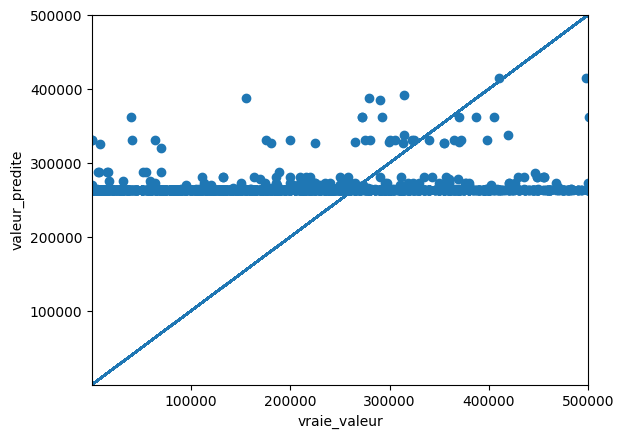

In [18]:
plt.scatter(y_test, y_pred_test)
plt.plot(y_test, y_test)
plt.xlim(1e2,5e5)
plt.ylim(1e2,5e5)
plt.ylabel('valeur_predite')
plt.xlabel('vraie_valeur')

# RandomForestRegressor

In [19]:
pipe_path_rf = "../model/20251023-12h32m43_rf.pkl"
data_path = "../data/clean/dvf.csv"

In [20]:
pipe_rf = load_pipeline(pipe_path_rf)

In [21]:
# Get scaled data
X_test_scaled_rf = pipe_rf.named_steps['scaler'].transform(X_test)

In [22]:
# SHAP analysis
explainer = shap.TreeExplainer(pipe_rf.named_steps['rf'])
shap_values = explainer.shap_values(X_test_scaled_rf)

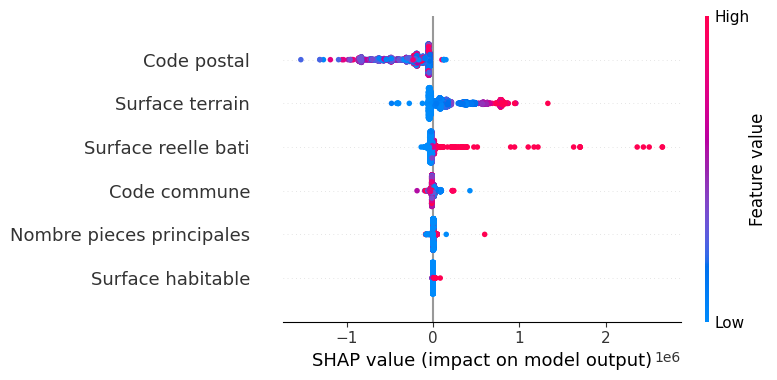

In [23]:
# Visualizations
shap.summary_plot(shap_values, X_test_scaled_rf, feature_names=X.columns)

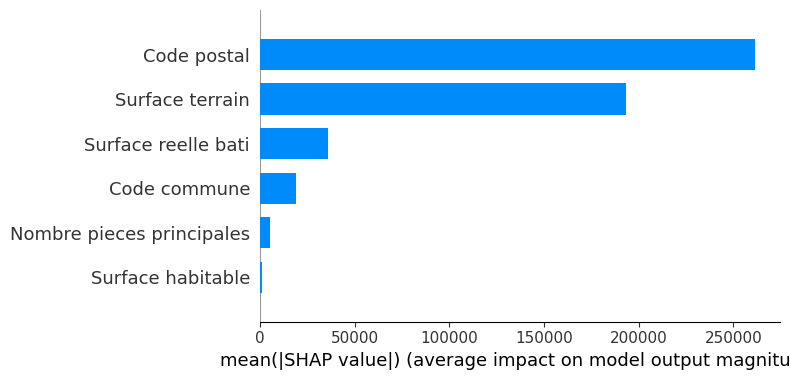

In [24]:
# Feature importance plot
shap.summary_plot(shap_values, X_test_scaled_rf, feature_names=X.columns, plot_type="bar")

In [25]:
# Individual prediction explanation
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test_scaled_rf[0], 
                feature_names=X.columns)

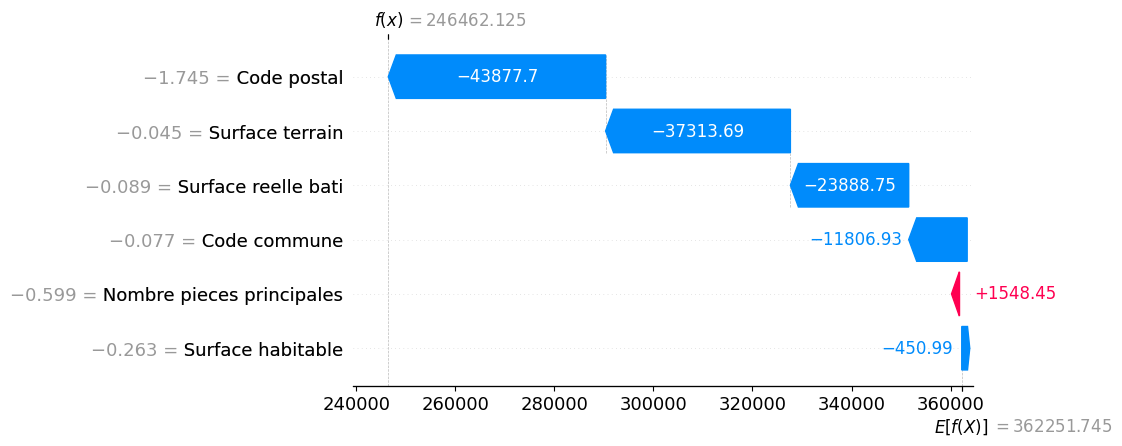

In [26]:
# Waterfall plot for single prediction
shap.plots.waterfall(shap.Explanation(values=shap_values[0], 
                                       base_values=explainer.expected_value,
                                       data=X_test_scaled_rf[0],
                                       feature_names=X.columns))

In [27]:
rs = np.random.RandomState(0)
df = pd.DataFrame(X_test_scaled_rf)
df.columns = X_test.columns
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,Code postal,Code commune,Surface habitable,Nombre pieces principales,Surface reelle bati,Surface terrain
Code postal,1.000000,0.220739,-0.098365,-0.005556,0.016339,0.038674
Code commune,0.220739,1.000000,-0.062277,0.010471,0.023900,0.036694
Surface habitable,-0.098365,-0.062277,1.000000,0.193384,0.072972,-0.097213
Nombre pieces principales,-0.005556,0.010471,0.193384,1.000000,0.232598,-0.111254
Surface reelle bati,0.016339,0.023900,0.072972,0.232598,1.000000,-0.037290
Surface terrain,0.038674,0.036694,-0.097213,-0.111254,-0.037290,1.000000


In [28]:
y_pred_test_rf = pipe_rf.predict(X_test)

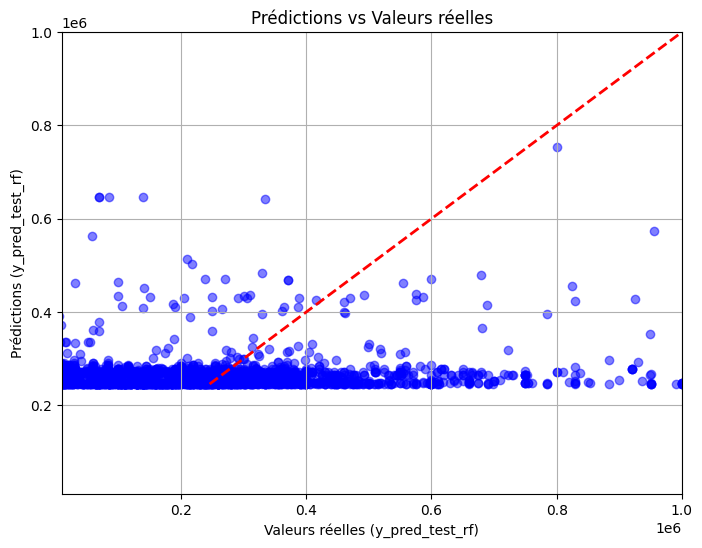

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_rf, alpha=0.5, color='blue')
plt.plot([min(y_pred_test_rf), max(y_pred_test_rf)], [min(y_pred_test_rf), max(y_pred_test_rf)], '--r', linewidth=2)  # Ligne idéale y=x
plt.xlabel('Valeurs réelles (y_pred_test_rf)')
plt.ylabel('Prédictions (y_pred_test_rf)')
plt.title('Prédictions vs Valeurs réelles')
plt.grid(True)
plt.xlim(1e4, 1e6)
plt.ylim(1e4, 1e6)
plt.show()

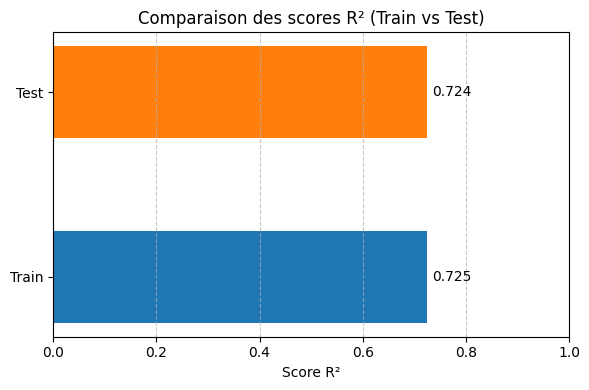

In [43]:
# Données
scores = [0.7254344288834348, 0.7238928155416253]
labels = ['Train', 'Test']
colors = ['#1f77b4', '#ff7f0e']  # Bleu et orange pour différencier

# Création du graphique
plt.figure(figsize=(6, 4))
bars = plt.barh(labels, scores, color=colors, height=0.5)

# Ajouter les valeurs sur les barres
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01,  # Position x (juste après la barre)
             bar.get_y() + bar.get_height()/2,  # Position y (centré verticalement)
             f'{width:.3f}',  # Valeur du score
             va='center', ha='left')

# Personnalisation
plt.xlabel('Score R²')
plt.title('Comparaison des scores R² (Train vs Test)')
plt.xlim(0, 1)  # Le R² est compris entre 0 et 1
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Afficher
plt.tight_layout()
plt.show()


# XGBoost

In [30]:
pipe_path_xg = "../model/20251023-14h30m14_xg.pkl"
data_path = "../data/clean/dvf.csv"

In [31]:
pipe_xg = load_pipeline(pipe_path_xg)

In [32]:
# Get scaled data
X_test_scaled_xg = pipe_xg.named_steps['scaler'].transform(X_test)

In [34]:
# SHAP analysis
explainer = shap.TreeExplainer(pipe_xg.named_steps['xg'])
shap_values = explainer.shap_values(X_test_scaled_xg)

ValueError: could not convert string to float: '[3.6261344E5]'

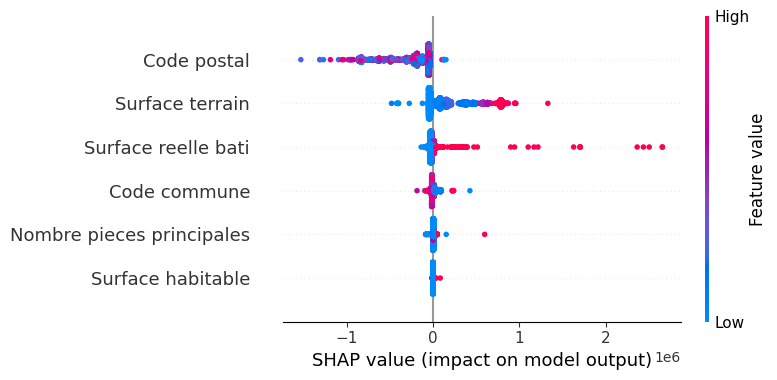

In [35]:
# Visualizations
shap.summary_plot(shap_values, X_test_scaled_xg, feature_names=X.columns)

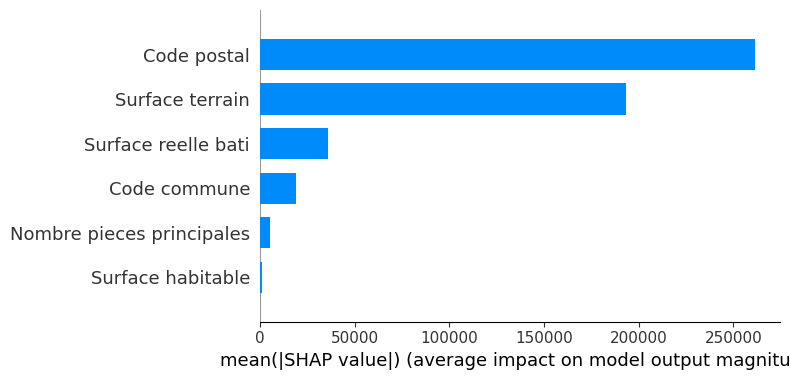

In [36]:
# Feature importance plot
shap.summary_plot(shap_values, X_test_scaled_xg, feature_names=X.columns, plot_type="bar")

In [37]:
# Individual prediction explanation
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test_scaled_xg[0], 
                feature_names=X.columns)

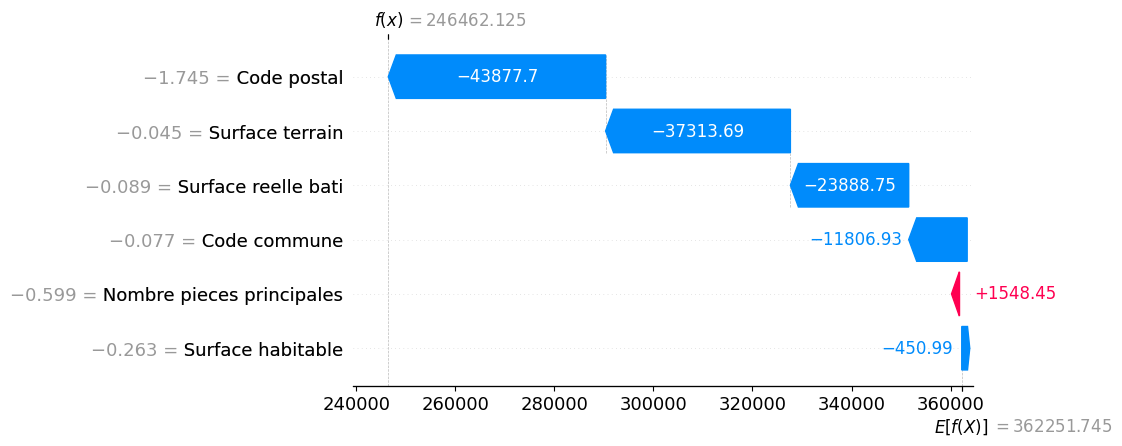

In [38]:
# Waterfall plot for single prediction
shap.plots.waterfall(shap.Explanation(values=shap_values[0], 
                                       base_values=explainer.expected_value,
                                       data=X_test_scaled_xg[0],
                                       feature_names=X.columns))

In [39]:
rs = np.random.RandomState(0)
df = pd.DataFrame(X_test_scaled_xg)
df.columns = X_test.columns
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,Code postal,Code commune,Surface habitable,Nombre pieces principales,Surface reelle bati,Surface terrain
Code postal,1.000000,0.220739,-0.098365,-0.005556,0.016339,0.038674
Code commune,0.220739,1.000000,-0.062277,0.010471,0.023900,0.036694
Surface habitable,-0.098365,-0.062277,1.000000,0.193384,0.072972,-0.097213
Nombre pieces principales,-0.005556,0.010471,0.193384,1.000000,0.232598,-0.111254
Surface reelle bati,0.016339,0.023900,0.072972,0.232598,1.000000,-0.037290
Surface terrain,0.038674,0.036694,-0.097213,-0.111254,-0.037290,1.000000


In [40]:
y_pred_test_xg = pipe_xg.predict(X_test)

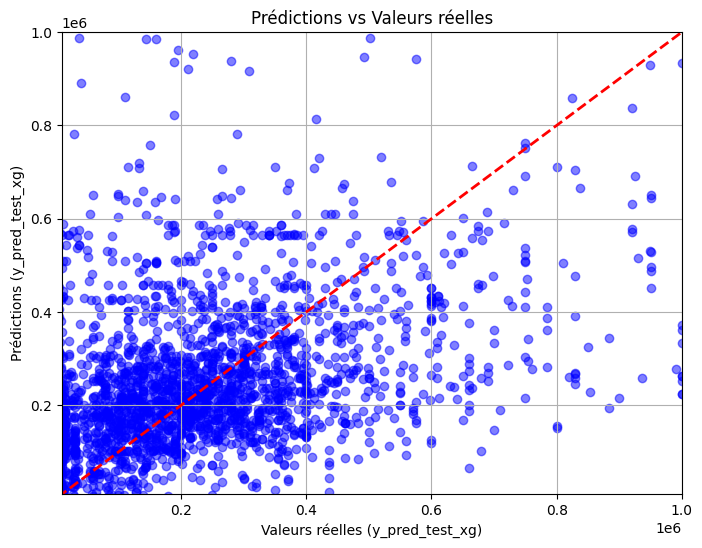

In [41]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_xg, alpha=0.5, color='blue')
plt.plot([min(y_pred_test_xg), max(y_pred_test_xg)], [min(y_pred_test_xg), max(y_pred_test_xg)], '--r', linewidth=2)  # Ligne idéale y=x
plt.xlabel('Valeurs réelles (y_pred_test_xg)')
plt.ylabel('Prédictions (y_pred_test_xg)')
plt.title('Prédictions vs Valeurs réelles')
plt.grid(True)
plt.xlim(1e4, 1e6)
plt.ylim(1e4, 1e6)
plt.show()

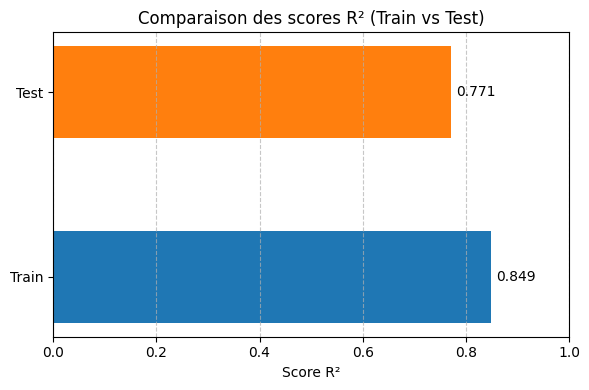

In [44]:
# Données
scores = [0.8490156092236925, 0.7713512490042018]
labels = ['Train', 'Test']
colors = ['#1f77b4', '#ff7f0e']  # Bleu et orange pour différencier

# Création du graphique
plt.figure(figsize=(6, 4))
bars = plt.barh(labels, scores, color=colors, height=0.5)

# Ajouter les valeurs sur les barres
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01,  # Position x (juste après la barre)
             bar.get_y() + bar.get_height()/2,  # Position y (centré verticalement)
             f'{width:.3f}',  # Valeur du score
             va='center', ha='left')

# Personnalisation
plt.xlabel('Score R²')
plt.title('Comparaison des scores R² (Train vs Test)')
plt.xlim(0, 1)  # Le R² est compris entre 0 et 1
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Afficher
plt.tight_layout()
plt.show()
